<a href="https://colab.research.google.com/github/olcaykursun/ML/blob/main/Spring2026/pytorch_mnist_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Compute TRAIN statistics ----
raw_train = datasets.MNIST("./data", train=True, download=True,
                           transform=transforms.ToTensor())

loader = DataLoader(raw_train, batch_size=1024, shuffle=False)

mean = 0.0
sq_mean = 0.0
num_pixels = 0

for x, _ in loader:
    # x shape: [B, C, H, W]
    b, c, h, w = x.shape

    num_pixels += b * h * w

    mean    += x.sum(dim=[0,2,3])
    sq_mean += (x**2).sum(dim=[0,2,3])

mean = mean / num_pixels
std  = (sq_mean / num_pixels - mean**2).sqrt()

print("Mean:", mean.item(), "Std:", std.item())

# ---- Base transform (always applied) ----
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# ---- Training transform = augmentation + base ----
train_transform = transforms.Compose([
    transforms.RandomRotation(5),
    base_transform
])

# ---- Validation/Test transform = base only ----
eval_transform = base_transform

# ---- Datasets ----
full_train = datasets.MNIST("./data", train=True,
                            transform=train_transform)

test_dataset = datasets.MNIST("./data", train=False,
                              transform=eval_transform)

# Split train → train + validation
val_size = 10000
train_size = len(full_train) - val_size

train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_dataset, batch_size=64,
                          pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(test_dataset, batch_size=64,
                          pin_memory=(device.type=="cuda"))

# ---- Tiny CNN ----
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7,128), nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self, x): return self.net(x)

model = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---- Train one epoch ----
def train_epoch():
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

# ---- Evaluate ----
def evaluate(loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
    return 100 * correct / len(loader.dataset)

# ---- Run ----
for epoch in range(2):
    train_epoch()
    print(f"Epoch {epoch+1}: val_acc={evaluate(val_loader):.2f}%")

print("Test accuracy:", evaluate(test_loader))

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 166kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.82MB/s]


Mean: 0.13066047430038452 Std: 0.30810782313346863
Epoch 1: val_acc=98.21%
Epoch 2: val_acc=98.24%
Epoch 3: val_acc=98.47%
Epoch 4: val_acc=98.67%
Epoch 5: val_acc=98.96%
Test accuracy: 98.99


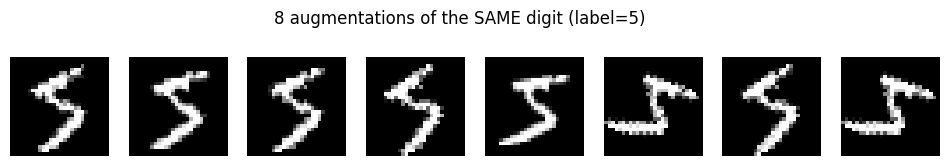

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# --- Augmentation pipeline ---
aug_transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

# --- Load MNIST WITHOUT transform ---
mnist = datasets.MNIST("./data", train=True, download=True, transform=None)

# Get the first raw image (PIL image)
img, label = mnist[0]

# --- Create multiple augmented versions ---
num_versions = 8
augmented_images = [aug_transform(img) for _ in range(num_versions)]

# --- Plot them ---
fig, axes = plt.subplots(1, num_versions, figsize=(12, 2))

for i in range(num_versions):
    axes[i].imshow(augmented_images[i].squeeze(), cmap="gray")
    axes[i].axis("off")

plt.suptitle(f"{num_versions} augmentations of the SAME digit (label={label})")
plt.show()

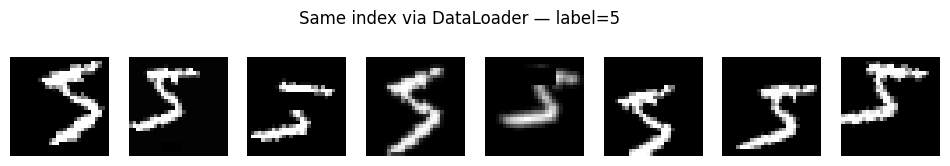

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# --- Training transform with augmentation ---
train_transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,            # rotation
        translate=(0.15, 0.15),# shifts
        scale=(0.9, 1.1),      # zoom in/out
        shear=10               # slant
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.3),

    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2)
    ], p=0.3),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.3,
        scale=(0.02, 0.08),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(mean, std)
])

# --- Dataset WITH transform attached ---
mnist = datasets.MNIST("./data", train=True, download=True,
                       transform=train_transform)

# --- Force loader to use ONLY index 0 ---
subset = Subset(mnist, [0])

loader = DataLoader(subset, batch_size=1, shuffle=False)

# --- Fetch multiple times ---
versions = []

for _ in range(8):
    for img, label in loader:
        versions.append(img[0])          # remove batch dim

# --- Plot results ---
fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i in range(8):
    axes[i].imshow(versions[i].squeeze(), cmap="gray")
    axes[i].axis("off")

plt.suptitle(f"Same index via DataLoader — label={label.item()}")
plt.show()